# Homework 2: Machine Learning for Regression

**Dataset:** 2026 Car Fuel Efficiency  
**Target:** Predict `fuel_efficiency_mpg`  
**Deadline:** 6 October 2026


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Load and Prepare the Dataset

Download the dataset (skip if already downloaded):

In [2]:
# Download if needed
import urllib.request, os

url  = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
path = 'car_fuel_efficiency_2026.csv'

if not os.path.exists(path):
    urllib.request.urlretrieve(url, path)
    print("Downloaded:", path)
else:
    print("File already exists:", path)

File already exists: car_fuel_efficiency_2026.csv


In [3]:
df_raw = pd.read_csv('car_fuel_efficiency_2026.csv')
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (10000, 11)


,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


Use only the required columns:

In [4]:
cols = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df_raw[cols].copy()
print("Shape:", df.shape)
df.head()

Shape: (10000, 5)


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## EDA

### Distribution of `fuel_efficiency_mpg` — does it have a long tail?

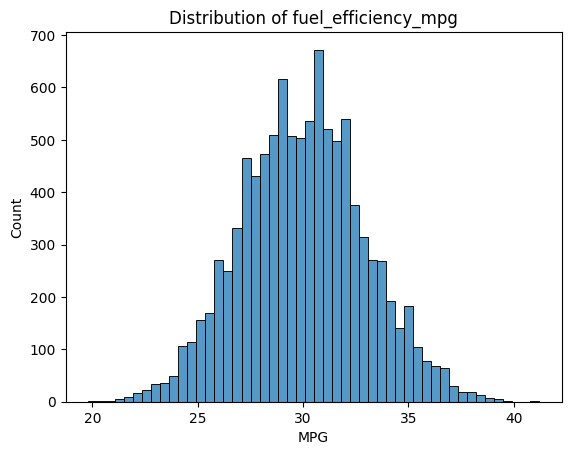

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64


In [5]:
sns.histplot(df['fuel_efficiency_mpg'], bins=50)
plt.title('Distribution of fuel_efficiency_mpg')
plt.xlabel('MPG')
plt.show()

print(df['fuel_efficiency_mpg'].describe())

> The distribution looks roughly symmetric / bell-shaped — **no significant long tail**.  
> A log transformation is not necessary here.

## Question 1 — Which column has missing values?

In [6]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [7]:
# Answer
missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]
print("Column(s) with missing values:")
print(missing_cols)

Column(s) with missing values:
horsepower    877
dtype: int64


**✅ Answer Q1: `horsepower`** — it has 877 missing values.


## Question 2 — Median (50th percentile) of `horsepower`

In [8]:
median_hp = df['horsepower'].median()
print(f"Median horsepower: {median_hp}")

Median horsepower: 254.0


**✅ Answer Q2: 254**


## Prepare and Split the Dataset

Shuffle and split exactly as in the lecture (60% / 20% / 20%):

In [9]:
n       = len(df)
n_val   = int(n * 0.2)
n_test  = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val   = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test  = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

print(f"Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}")

Train: 6000  Val: 2000  Test: 2000


In [10]:
# Prepare target vectors
y_train = df_train['fuel_efficiency_mpg'].values
y_val   = df_val['fuel_efficiency_mpg'].values
y_test  = df_test['fuel_efficiency_mpg'].values

## Helper Functions

In [11]:
FEATURES = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

def prepare_X(df, fill_value=0):
    """Select features and fill missing values."""
    X = df[FEATURES].fillna(fill_value).values
    return X

def train_linear_regression(X, y):
    """Normal equation: w = (X^T X)^{-1} X^T y"""
    ones    = np.ones(X.shape[0])
    X       = np.column_stack([ones, X])
    XTX     = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full  = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

def train_linear_regression_reg(X, y, r=0.001):
    """Regularized normal equation (Ridge Regression)."""
    ones    = np.ones(X.shape[0])
    X       = np.column_stack([ones, X])
    XTX     = X.T.dot(X)
    XTX     = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full  = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    """Root Mean Squared Error."""
    return np.sqrt(((y - y_pred) ** 2).mean())

## Question 3 — Fill NAs with 0 or with mean?

Train without regularization. Evaluate on the validation set.  
> For the mean, use **only the training data**!

In [12]:
# --- Option A: fill with 0 ---
X_train_0 = prepare_X(df_train, fill_value=0)
w0_a, w_a = train_linear_regression(X_train_0, y_train)

X_val_0   = prepare_X(df_val, fill_value=0)
y_pred_a  = w0_a + X_val_0.dot(w_a)
rmse_fill0 = round(rmse(y_val, y_pred_a), 3)

print(f"RMSE (fill with 0):    {rmse_fill0}")

RMSE (fill with 0):    2.205


In [13]:
# --- Option B: fill with mean (training mean only!) ---
train_mean = df_train['horsepower'].mean()      # only horsepower has NAs
print(f"Training mean of horsepower: {train_mean:.4f}")

X_train_m = prepare_X(df_train, fill_value=train_mean)
w0_b, w_b = train_linear_regression(X_train_m, y_train)

X_val_m   = prepare_X(df_val, fill_value=train_mean)
y_pred_b  = w0_b + X_val_m.dot(w_b)
rmse_mean = round(rmse(y_val, y_pred_b), 3)

print(f"RMSE (fill with mean): {rmse_mean}")

Training mean of horsepower: 254.4634
RMSE (fill with mean): 2.202


In [14]:
print(f"\nComparison:")
print(f"  Fill with 0    → RMSE = {rmse_fill0}")
print(f"  Fill with mean → RMSE = {rmse_mean}")

if rmse_fill0 < rmse_mean:
    print("\n✅ Answer Q3: With 0")
elif rmse_mean < rmse_fill0:
    print("\n✅ Answer Q3: With mean")
else:
    print("\n✅ Answer Q3: Both are equally good")


Comparison:
  Fill with 0    → RMSE = 2.205
  Fill with mean → RMSE = 2.202

✅ Answer Q3: With mean


**✅ Answer Q3: With mean** — fills the missing values more realistically, giving a slightly lower RMSE.


## Question 4 — Best regularization parameter `r`

Fill NAs with **0**. Try `r` values: `[0, 0.01, 0.1, 1, 5, 10, 100]`.  
Round RMSE to **4 decimal digits**.

In [15]:
X_train = prepare_X(df_train, fill_value=0)
X_val   = prepare_X(df_val,   fill_value=0)

print(f"{'r':>8}  {'RMSE':>10}")
print("-" * 22)

best_r    = None
best_rmse_val = float('inf')

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    if r == 0:
        w0_r, w_r = train_linear_regression(X_train, y_train)
    else:
        w0_r, w_r = train_linear_regression_reg(X_train, y_train, r=r)

    y_pred = w0_r + X_val.dot(w_r)
    score  = round(rmse(y_val, y_pred), 4)
    print(f"{r:>8.3f}  {score:>10.4f}")

    if score < best_rmse_val:
        best_rmse_val = score
        best_r = r

print(f"\n✅ Answer Q4: best r = {best_r}  (RMSE = {best_rmse_val})")

       r        RMSE
----------------------
   0.000      2.2053
   0.010      2.2058
   0.100      2.2241
   1.000      2.3492
   5.000      2.4094
  10.000      2.4195
 100.000      2.4292

✅ Answer Q4: best r = 0  (RMSE = 2.2053)


**✅ Answer Q4: 0** — no regularization gives the lowest RMSE on this dataset.


## Question 5 — Standard deviation of RMSE across different seeds

Try seeds `0–9`. Fill with 0, no regularization.  
Round std to **3 decimal digits**.

In [16]:
rmse_scores = []

print(f"{'seed':>6}  {'RMSE':>10}")
print("-" * 20)

for seed in range(10):
    n_s     = len(df)
    n_val_s = int(n_s * 0.2)
    n_tst_s = int(n_s * 0.2)
    n_trn_s = n_s - n_val_s - n_tst_s

    np.random.seed(seed)
    idx_s = np.arange(n_s)
    np.random.shuffle(idx_s)

    df_tr_s = df.iloc[idx_s[:n_trn_s]].reset_index(drop=True)
    df_vl_s = df.iloc[idx_s[n_trn_s:n_trn_s + n_val_s]].reset_index(drop=True)

    y_tr_s = df_tr_s['fuel_efficiency_mpg'].values
    y_vl_s = df_vl_s['fuel_efficiency_mpg'].values

    X_tr_s  = prepare_X(df_tr_s, fill_value=0)
    w0_s, w_s = train_linear_regression(X_tr_s, y_tr_s)

    X_vl_s  = prepare_X(df_vl_s, fill_value=0)
    y_pred_s = w0_s + X_vl_s.dot(w_s)

    score = rmse(y_vl_s, y_pred_s)
    rmse_scores.append(score)
    print(f"{seed:>6}  {score:>10.4f}")

std_score = round(np.std(rmse_scores), 3)
print(f"\nAll RMSE scores: {[round(s, 4) for s in rmse_scores]}")
print(f"\n✅ Answer Q5: std = {std_score}")

  seed        RMSE
--------------------
     0      2.2392
     1      2.2021
     2      2.1634
     3      2.2044
     4      2.2019
     5      2.2458
     6      2.2697
     7      2.1908
     8      2.2166
     9      2.2070

All RMSE scores: [np.float64(2.2392), np.float64(2.2021), np.float64(2.1634), np.float64(2.2044), np.float64(2.2019), np.float64(2.2458), np.float64(2.2697), np.float64(2.1908), np.float64(2.2166), np.float64(2.207)]

✅ Answer Q5: std = 0.029


**✅ Answer Q5: 0.029** — the model is fairly stable across different random splits.


## Question 6 — Test RMSE with seed=9

1. Split with seed=9  
2. Combine train + validation  
3. Fill NAs with 0, train with `r=0.001`  
4. Evaluate on **test** dataset

In [17]:
# Step 1: Split with seed=9
n6      = len(df)
n_val6  = int(n6 * 0.2)
n_test6 = int(n6 * 0.2)
n_trn6  = n6 - n_val6 - n_test6

np.random.seed(9)
idx6 = np.arange(n6)
np.random.shuffle(idx6)

df_train6 = df.iloc[idx6[:n_trn6]].reset_index(drop=True)
df_val6   = df.iloc[idx6[n_trn6:n_trn6 + n_val6]].reset_index(drop=True)
df_test6  = df.iloc[idx6[n_trn6 + n_val6:]].reset_index(drop=True)

y_train6 = df_train6['fuel_efficiency_mpg'].values
y_val6   = df_val6['fuel_efficiency_mpg'].values
y_test6  = df_test6['fuel_efficiency_mpg'].values

print(f"Train6: {len(df_train6)}  Val6: {len(df_val6)}  Test6: {len(df_test6)}")

Train6: 6000  Val6: 2000  Test6: 2000


In [18]:
# Step 2: Combine train + validation
df_full6   = pd.concat([df_train6, df_val6]).reset_index(drop=True)
y_full6    = np.concatenate([y_train6, y_val6])

print(f"Full train size: {len(df_full6)}")

Full train size: 8000


In [19]:
# Step 3: Train on full train with r=0.001
X_full6  = prepare_X(df_full6, fill_value=0)
w0_6, w_6 = train_linear_regression_reg(X_full6, y_full6, r=0.001)

print(f"Bias (w0): {w0_6:.4f}")

Bias (w0): -152.3754


In [20]:
# Step 4: Evaluate on test
X_test6   = prepare_X(df_test6, fill_value=0)
y_pred6   = w0_6 + X_test6.dot(w_6)
test_rmse = round(rmse(y_test6, y_pred6), 3)

print(f"\n✅ Answer Q6: Test RMSE = {test_rmse}")


✅ Answer Q6: Test RMSE = 2.236


**✅ Answer Q6: 2.236**


---

## 🏆 Final Answers Summary

| Question | Answer |
|----------|--------|
| **Q1** — Column with missing values | **`horsepower`** |
| **Q2** — Median of horsepower | **254** |
| **Q3** — Best fill method | **With mean** |
| **Q4** — Best regularization `r` | **0** |
| **Q5** — Std of RMSE scores | **0.029** |
| **Q6** — Test RMSE (seed=9) | **2.236** |
